<a href="https://colab.research.google.com/github/Sanath-cmd/Internship_ITT/blob/main/Hierarchial_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [65]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch
from sklearn.metrics import silhouette_score


In [50]:
df = pd.read_csv('/content/drive/MyDrive/Country-data.csv')
df

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


In [52]:
df = df.drop('country', axis = 1)
df

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...
162,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


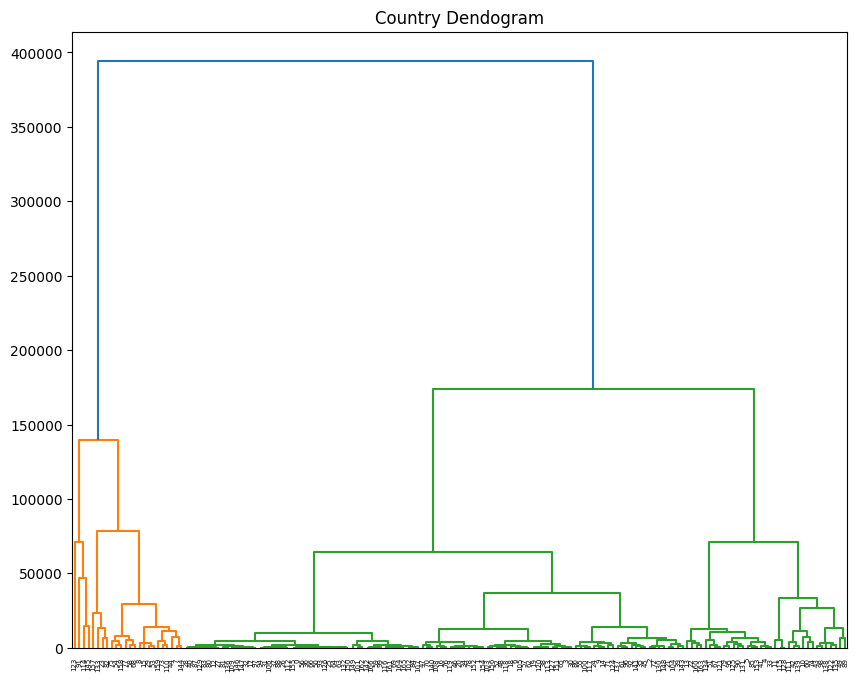

In [67]:
plt.figure(figsize=(10, 8))
plt.title("Country Dendogram")
dend = sch.dendrogram(sch.linkage(df, method= 'ward'))
plt.show(dend)


In [70]:
model = AgglomerativeClustering(n_clusters= 5, metric= 'euclidean', linkage= 'ward')
labels = model.fit_predict(df)
print(labels)

[2 2 2 2 1 1 2 3 3 2 1 1 2 1 2 3 2 2 2 2 2 2 1 4 2 2 2 2 2 3 2 2 2 1 2 2 2
 2 2 2 2 1 1 1 3 2 2 2 2 1 2 1 2 3 3 2 2 2 3 2 1 2 2 2 2 2 2 1 3 2 2 2 2 3
 1 3 2 3 2 1 2 2 4 2 2 1 2 2 2 1 1 0 2 2 2 1 2 2 1 2 2 2 2 2 2 2 2 2 2 2 3
 1 2 2 0 1 2 2 2 2 2 1 1 0 2 1 2 2 1 2 2 1 2 4 1 1 2 2 1 1 2 2 2 2 3 0 2 2
 2 2 2 2 2 1 2 2 2 4 3 3 1 2 2 1 2 2 2]


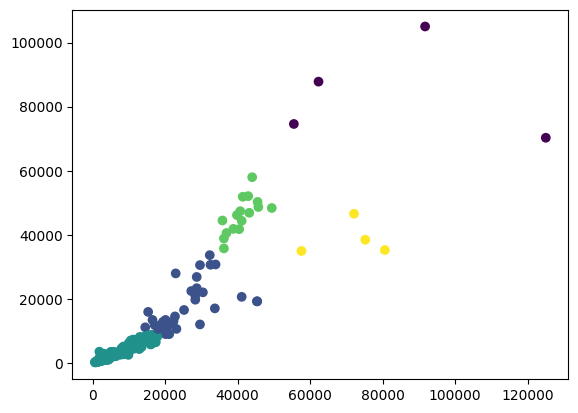

In [71]:
plt.scatter(df['income'], df['gdpp'], c = labels)

In [72]:
score = silhouette_score(df,labels)
score

np.float64(0.6130870942691207)